In [1]:
from pathlib import Path
import sys
import math
import os
import json

# Configuración del proyecto
PROJECT_ROOT = Path.cwd().parent if 'notebooks' in str(Path.cwd()) else Path.cwd()

# Agregar el directorio raíz del proyecto al sys.path para importar módulos personalizados
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torch
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image

# Semilla para reproducibilidad
random.seed(50)
import yaml


from src.utils import get_train_transform, get_val_transform, plot_training_history, show_classification_metrics, show_roc_curve, show_confusion_matrix, show_gradcam
from src.models import RadriografiaEfficientNetB3
from src.train import train_model
from src.evaluate import evaluate_model
from src.inference import predict_and_show

In [2]:
CONFIG_PATH = PROJECT_ROOT / "config" / "config.yaml"
# Cargar la configuración del proyecto desde el archivo YAML
with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

In [3]:
PROCESSED_PATH = PROJECT_ROOT / config["paths"]["processed_dataset_path"]
MODEL_NAME = config["model"]["name"]

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
def make_dataset_df(base_dir: str) -> pd.DataFrame:
    data = []
    # Fractured = 1, Non_fractured = 0
    categories = {'non_fractured': 0, 'fractured': 1}

    if base_dir is None:
        print("Error: base_dir es None. Asegúrate de que las carpetas 'fractured' y 'non_fractured' estén en el dataset.")
        return pd.DataFrame(columns=['file_path', 'label'])

    for folder_name, label in categories.items():
        folder_path = os.path.join(base_dir, folder_name)
        if not os.path.exists(folder_path):
            print(f'Carpeta no encontrada: {folder_path}')
            continue

        for file_name in os.scandir(folder_path):
            if file_name.is_file() and file_name.name.lower().endswith(('.png', '.jpg', '.jpeg')):
                data.append((file_name.path, label))

    df = pd.DataFrame(data, columns=['file_path', 'label'])
    return df

df = make_dataset_df(PROCESSED_PATH)
print('Total de imagenes:', df.shape[0])
print('Distribucion de clases:\n', df['label'].value_counts())

Total de imagenes: 4819
Distribucion de clases:
 label
0    3366
1    1453
Name: count, dtype: int64


In [ ]:
# Split: Train (80%), Val (10%), Test (10%)
if df.empty:
    print('El DataFrame está vacío. No hay imágenes para dividir.')
    train_df = pd.DataFrame(columns=df.columns)
    val_df = pd.DataFrame(columns=df.columns)
    test_df = pd.DataFrame(columns=df.columns)
else:
    train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(f'Train set: {train_df.shape[0]} imagenes')
print(f'Validation set: {val_df.shape[0]} imagenes')
print(f'Test set: {test_df.shape[0]} imagenes')

Train set: 3855 imagenes
Validation set: 482 imagenes
Test set: 482 imagenes


In [ ]:
class BoneFractureDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['file_path']
        label = self.dataframe.iloc[idx]['label']

        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f'Error leyendo {img_path}: {e}')
            image = Image.new('RGB', (224, 224), 0)

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
best_model_path_tf = PROJECT_ROOT / config["paths"]["model_path_tf"]
save_historial_path_tf = PROJECT_ROOT / config["paths"]["historial_path_tf"]
best_model_path_ft1 = PROJECT_ROOT / config["paths"]["model_path_ft1"]
save_historial_path_ft1 = PROJECT_ROOT / config["paths"]["historial_path_ft1"]
best_model_path_ft2 = PROJECT_ROOT / config["paths"]["model_path_ft2"]
save_historial_path_ft2 = PROJECT_ROOT / config["paths"]["historial_path_ft2"]
best_model_path_ft3 = PROJECT_ROOT / config["paths"]["model_path_ft3"]
save_historial_path_ft3 = PROJECT_ROOT / config["paths"]["historial_path_ft3"]

weight_decays = config["model"]["parameters"]["weight_decay"]
batch_size = config["model"]["parameters"]["batch_size"]
lrs = config["model"]["parameters"]["learning_rate"]
epochs_f = config["model"]["parameters"]["epochs_phases"]
patience = config["model"]["parameters"]["patience"]

In [ ]:
train_transform = get_train_transform()

test_val_transform = get_val_transform()

train_dataset = BoneFractureDataset(train_df, transform=train_transform)
val_dataset = BoneFractureDataset(val_df, transform=test_val_transform)
test_dataset = BoneFractureDataset(test_df, transform=test_val_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
model = RadriografiaEfficientNetB3(num_classes=2, model_name=MODEL_NAME, pretrained=True, freeze_backbone=True)
print('Modelo cargado en:', device)
torch.backends.cudnn.benchmark = True

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Modelo cargado en: cuda


In [ ]:
# Calcular pesos automáticamente basados en la distribución real del train_df
# 'balanced' usa n_samples / (n_classes * np.bincount(y))
labels_train = train_df['label'].values
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(labels_train),
                                     y=labels_train)

custom_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f'Aplicando pesos de clase manuales para sensibilidad: {custom_weights}')

model.unfreze_backbone(phase_num=0)
model.to(device)
criterion = nn.CrossEntropyLoss(weight=custom_weights)

# Optimizador configurado para las capas de la cabeza inicialmente
parameters_to_optimize = filter(lambda p: p.requires_grad, model.parameters())
optimizer = torch.optim.Adam(parameters_to_optimize, lr=float(lrs[0]), weight_decay=float(weight_decays[0]))

best_valid_recall = 0.0
patience = config["model"]["parameters"]["patience"]
early_stop_counter = 0

Aplicando pesos de clase manuales para sensibilidad: tensor([0.7157, 1.6588], device='cuda:0')


In [ ]:
history_tf = train_model(
    model, train_loader, val_loader, criterion, optimizer,
    num_epochs=epochs_f[0],
    save_best_model_path=best_model_path_tf,
    save_historial_path=save_historial_path_tf,
    device=device,
    metric='recall',
    patience=patience
)

Epoch 1/50 [Train]: 100%|██████████| 121/121 [01:12<00:00,  1.66it/s]


Época [1/50] | Train Loss: 0.5651 Acc: 0.7585 Recall: 0.6377 | Val Loss: 0.5722 Acc: 0.8216 Recall: 0.4452
[*] Nuevo mejor modelo guardado (recall: 0.4452) en: /content/checkpoints/radriografia_efficientnet_b3_tf.h5


Epoch 2/50 [Train]: 100%|██████████| 121/121 [00:56<00:00,  2.13it/s]


Época [2/50] | Train Loss: 0.4894 Acc: 0.7990 Recall: 0.7151 | Val Loss: 0.5066 Acc: 0.7780 Recall: 0.6575
[*] Nuevo mejor modelo guardado (recall: 0.6575) en: /content/checkpoints/radriografia_efficientnet_b3_tf.h5


Epoch 3/50 [Train]: 100%|██████████| 121/121 [00:54<00:00,  2.24it/s]


...

Época [29/50] | Train Loss: 0.4394 Acc: 0.8042 Recall: 0.7487 | Val Loss: 0.4671 Acc: 0.8382 Recall: 0.6027


Epoch 30/50 [Train]: 100%|██████████| 121/121 [00:53<00:00,  2.25it/s]


Época [30/50] | Train Loss: 0.4407 Acc: 0.8039 Recall: 0.7547 | Val Loss: 0.4550 Acc: 0.8444 Recall: 0.6712


Epoch 31/50 [Train]: 100%|██████████| 121/121 [00:54<00:00,  2.24it/s]


Época [31/50] | Train Loss: 0.4408 Acc: 0.8067 Recall: 0.7651 | Val Loss: 0.4488 Acc: 0.8382 Recall: 0.6918
Early stopping por falta de mejora en recall.


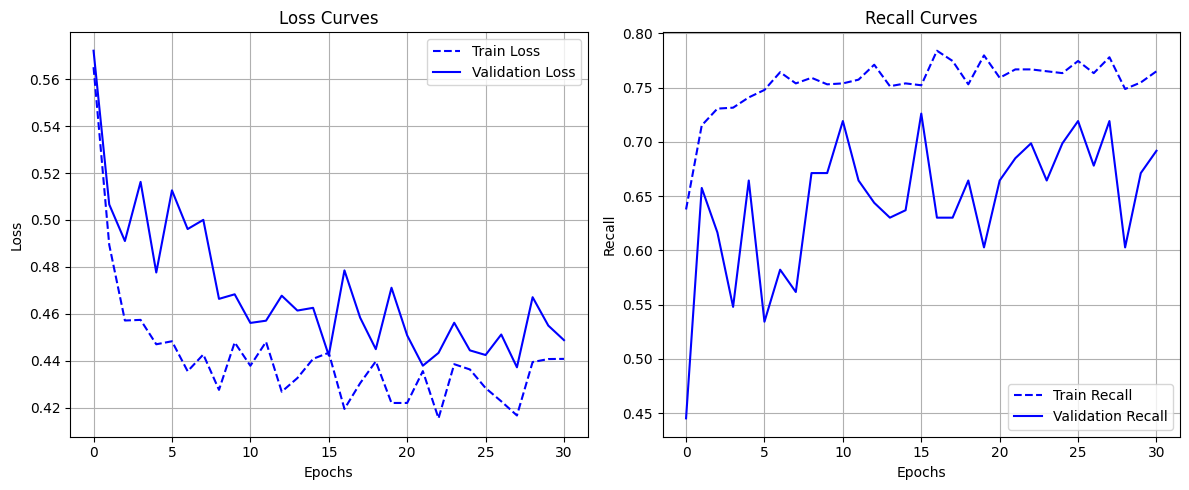

In [ ]:
plot_training_history(
    stages=[{'label': 'Stage 1', 'historial': history_tf}],
    metrics=('loss', 'recall'),
    figsize=(12, 5),
    layout='horizontal'
)

Testing: 100%|██████████| 16/16 [00:03<00:00,  4.07it/s]


Loss: 0.4183
Classification Report:
                 precision    recall  f1-score   support

No fractura (0)       0.90      0.83      0.86       337
   Fractura (1)       0.67      0.78      0.72       145

       accuracy                           0.82       482
      macro avg       0.78      0.81      0.79       482
   weighted avg       0.83      0.82      0.82       482



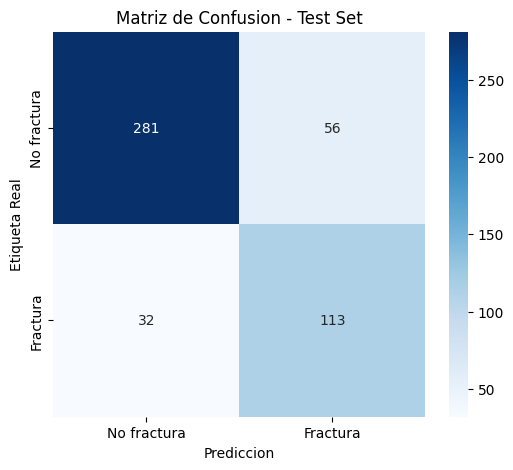

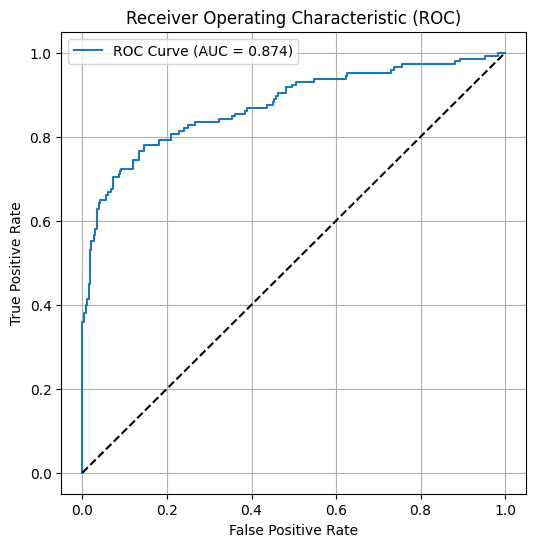

In [ ]:
if test_df.empty:
    print("El DataFrame de prueba está vacío. No hay datos para evaluar.")
else:
    resultados_test = evaluate_model(
        model, test_loader, criterion, device,
        model_path=best_model_path_tf
    )

    all_labels = resultados_test['labels']
    all_preds = resultados_test['preds']
    all_probs = resultados_test['probs']

    show_classification_metrics(all_labels, all_preds, target_names=['No fractura (0)', 'Fractura (1)'])
    show_confusion_matrix(all_labels, all_preds, target_names=['No fractura', 'Fractura'])
    show_roc_curve(all_labels, all_probs)

### Fase 2: Fine-Tuning de Capas Superiores
En esta etapa se desbloquean los últimos bloques del backbone para ajustar el modelo a patrones específicos de radiografías óseas, partiendo de los pesos obtenidos en la etapa de Transfer Learning.

In [ ]:
# 1. Descongelar las capas finales del backbone
# Desbloqueamos los últimos bloques y la capa de salida
model.unfreze_backbone(phase_num=1)

model.load_state_dict(torch.load(best_model_path_tf, map_location=device))

# 2. Configurar un Learning Rate mucho más bajo para no destruir lo aprendido
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=float(lrs[1]), weight_decay=float(weight_decays[1]))

# 3. Scheduler: Reduce el LR a la mitad si la validación no mejora en 3 épocas
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)


print("Capas superiores desbloqueadas. Optimizador y Scheduler configurados.")

Capas superiores desbloqueadas. Optimizador y Scheduler configurados.


In [ ]:
history_ft1 = train_model(
    model, train_loader, val_loader, criterion, optimizer,
    num_epochs=int(epochs_f[1]),
    save_best_model_path=best_model_path_ft1,
    save_historial_path=save_historial_path_ft1,
    device=device
)

Epoch 1/30 [Train]: 100%|██████████| 121/121 [01:09<00:00,  1.74it/s]


Época [1/30] | Train Loss: 0.4290 Acc: 0.7958 Recall: 0.7883 | Val Loss: 0.4591 Acc: 0.8361 Recall: 0.6507
[*] Nuevo mejor modelo guardado (acc: 0.8361) en: /content/checkpoints/radriografia_efficientnet_b3_ft1.h5


Epoch 2/30 [Train]: 100%|██████████| 121/121 [00:52<00:00,  2.29it/s]


Época [2/30] | Train Loss: 0.4070 Acc: 0.8304 Recall: 0.7762 | Val Loss: 0.4411 Acc: 0.8423 Recall: 0.6781
[*] Nuevo mejor modelo guardado (acc: 0.8423) en: /content/checkpoints/radriografia_efficientnet_b3_ft1.h5


Epoch 3/30 [Train]: 100%|██████████| 121/121 [00:54<00:00,  2.22it/s]


...

Época [28/30] | Train Loss: 0.3370 Acc: 0.8623 Recall: 0.8158 | Val Loss: 0.3784 Acc: 0.8714 Recall: 0.7534
[*] Nuevo mejor modelo guardado (acc: 0.8714) en: /content/checkpoints/radriografia_efficientnet_b3_ft1.h5


Epoch 29/30 [Train]: 100%|██████████| 121/121 [00:55<00:00,  2.20it/s]


Época [29/30] | Train Loss: 0.3423 Acc: 0.8573 Recall: 0.8167 | Val Loss: 0.3771 Acc: 0.8589 Recall: 0.7260


Epoch 30/30 [Train]: 100%|██████████| 121/121 [00:56<00:00,  2.15it/s]


Época [30/30] | Train Loss: 0.3207 Acc: 0.8724 Recall: 0.8107 | Val Loss: 0.3683 Acc: 0.8672 Recall: 0.7534


### Evaluación de la Etapa 2
Visualización del progreso y métricas tras el primer ajuste fino de las capas superiores.

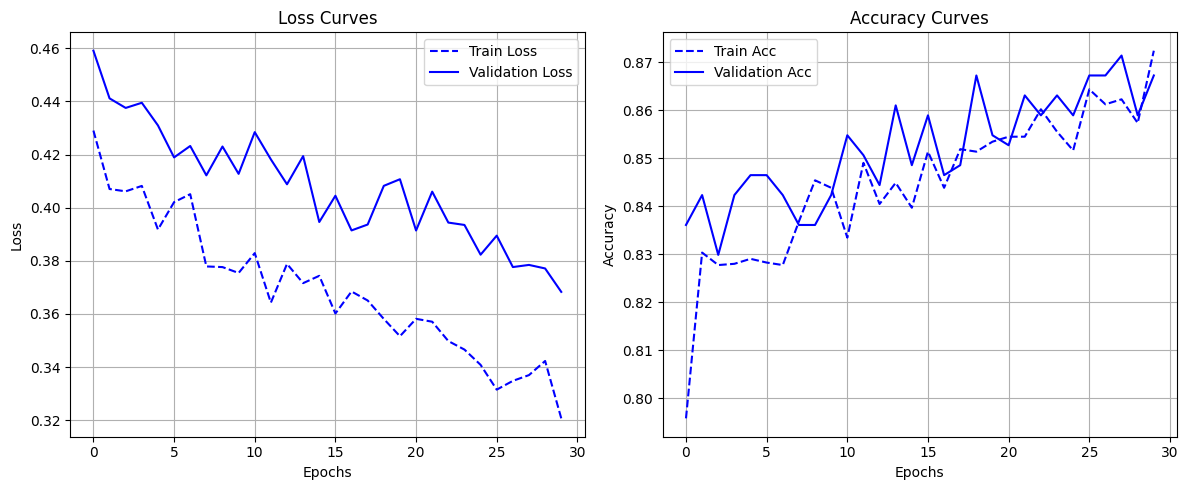

In [ ]:
plot_training_history(
    stages=[{'label': 'Stage 2', 'historial': history_ft1}],
    metrics=('loss', 'acc'),
    figsize=(12, 5),
    layout='horizontal'
)

Testing: 100%|██████████| 16/16 [00:03<00:00,  4.28it/s]



Loss: 0.3341
Classification Report:
                 precision    recall  f1-score   support

No fractura (0)       0.90      0.93      0.91       337
   Fractura (1)       0.82      0.77      0.79       145

       accuracy                           0.88       482
      macro avg       0.86      0.85      0.85       482
   weighted avg       0.88      0.88      0.88       482



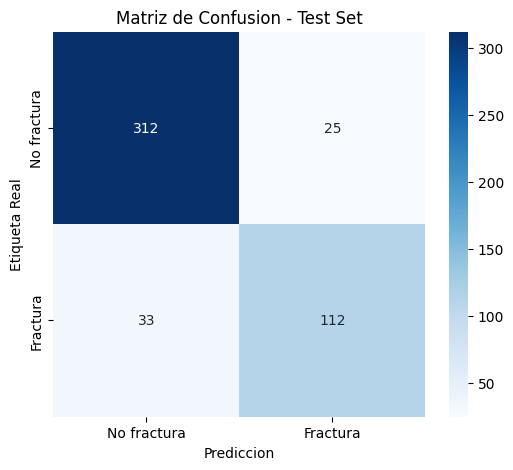

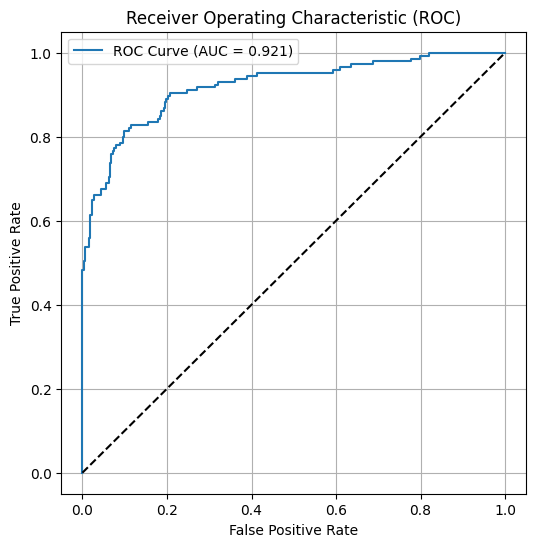

In [ ]:
if test_df.empty:
    print("El DataFrame de prueba está vacío. No hay datos para evaluar.")
else:
    resultados_test = evaluate_model(
        model, test_loader, criterion, device,
        model_path=best_model_path_ft1
    )

    all_labels = resultados_test['labels']
    all_preds = resultados_test['preds']
    all_probs = resultados_test['probs']

    show_classification_metrics(all_labels, all_preds, target_names=['No fractura (0)', 'Fractura (1)'])
    show_confusion_matrix(all_labels, all_preds, target_names=['No fractura', 'Fractura'])
    show_roc_curve(all_labels, all_probs)

### Fase 3: Fine-Tuning Intermedio (Bloques 3 y 4)
Descongelación de capas intermedias. Se busca mayor especialización del modelo reduciendo la tasa de aprendizaje para mantener la estabilidad de los pesos previamente ajustados.

In [ ]:
torch.cuda.empty_cache()

model.load_state_dict(torch.load(best_model_path_ft1, map_location=device))

model.unfreze_backbone(phase_num=2)

# 3. LR aún más bajo para preservar estabilidad
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=float(lrs[2]), weight_decay=float(weight_decays[2]))

print("Memoria limpia y capas listas para continuar.")

Memoria limpia y capas listas para continuar.


In [ ]:
history_ft2 = train_model(
    model, train_loader, val_loader, criterion, optimizer,
    num_epochs=int(epochs_f[2]),
    save_best_model_path=best_model_path_ft2,
    save_historial_path=save_historial_path_ft2,
    device=device
)

Epoch 1/25 [Train]: 100%|██████████| 121/121 [01:19<00:00,  1.52it/s]


Época [1/25] | Train Loss: 0.3232 Acc: 0.8664 Recall: 0.8124 | Val Loss: 0.3768 Acc: 0.8693 Recall: 0.7397
[*] Nuevo mejor modelo guardado (acc: 0.8693) en: /content/checkpoints/radriografia_efficientnet_b3_ft2.h5


Epoch 2/25 [Train]: 100%|██████████| 121/121 [00:57<00:00,  2.09it/s]


Época [2/25] | Train Loss: 0.3300 Acc: 0.8617 Recall: 0.8107 | Val Loss: 0.3678 Acc: 0.8631 Recall: 0.7877


Epoch 3/25 [Train]: 100%|██████████| 121/121 [00:57<00:00,  2.09it/s]


...

Época [23/25] | Train Loss: 0.2704 Acc: 0.8981 Recall: 0.8511 | Val Loss: 0.3468 Acc: 0.8942 Recall: 0.7466


Epoch 24/25 [Train]: 100%|██████████| 121/121 [01:00<00:00,  2.00it/s]


Época [24/25] | Train Loss: 0.2689 Acc: 0.8973 Recall: 0.8503 | Val Loss: 0.3350 Acc: 0.8942 Recall: 0.7808


Epoch 25/25 [Train]: 100%|██████████| 121/121 [00:58<00:00,  2.07it/s]


Época [25/25] | Train Loss: 0.2625 Acc: 0.8991 Recall: 0.8589 | Val Loss: 0.3284 Acc: 0.8921 Recall: 0.7877


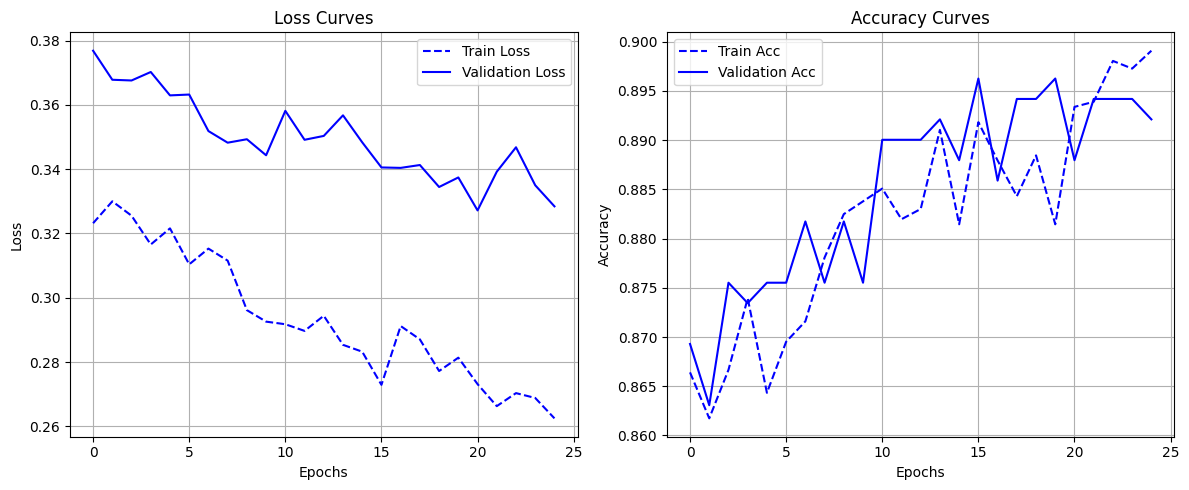

In [ ]:
plot_training_history(
    stages=[{'label': 'Stage 3', 'historial': history_ft2}],
    metrics=('loss', 'acc'),
    figsize=(12, 5),
    layout='horizontal'
)

Testing: 100%|██████████| 16/16 [00:03<00:00,  4.12it/s]



Loss: 0.3015
Classification Report:
                 precision    recall  f1-score   support

No fractura (0)       0.92      0.91      0.91       337
   Fractura (1)       0.79      0.81      0.80       145

       accuracy                           0.88       482
      macro avg       0.85      0.86      0.86       482
   weighted avg       0.88      0.88      0.88       482



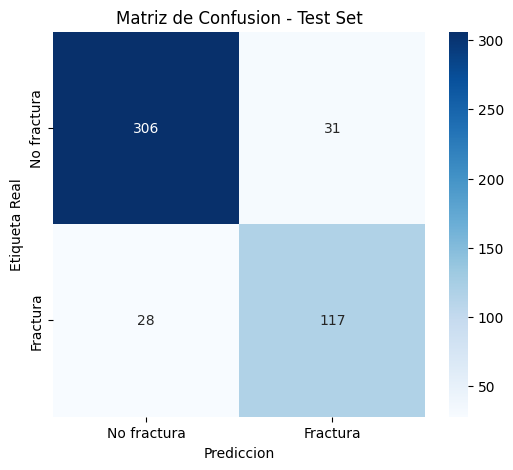

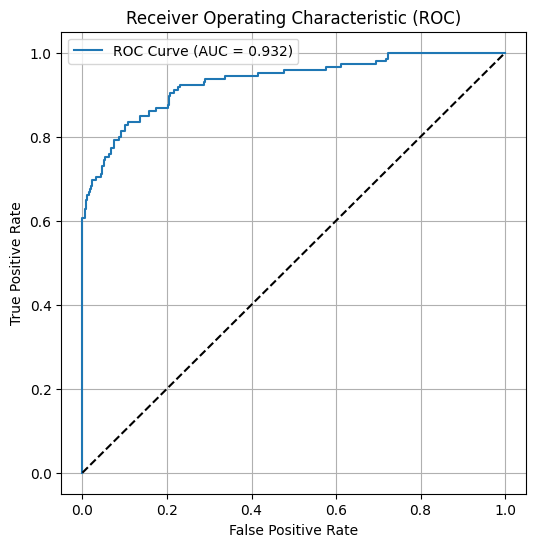

In [ ]:
if test_df.empty:
    print("El DataFrame de prueba está vacío. No hay datos para evaluar.")
else:
    resultados_test = evaluate_model(
        model, test_loader, criterion, device,
        model_path=best_model_path_ft2
    )

    all_labels = resultados_test['labels']
    all_preds = resultados_test['preds']
    all_probs = resultados_test['probs']

    show_classification_metrics(all_labels, all_preds, target_names=['No fractura (0)', 'Fractura (1)'])
    show_confusion_matrix(all_labels, all_preds, target_names=['No fractura', 'Fractura'])
    show_roc_curve(all_labels, all_probs)

### Fase 4: Fine-Tuning Profundo (Bloques 1 y 2)
Última etapa de entrenamiento donde se permite el ajuste de las capas iniciales (extractores de características de bajo nivel) para optimizar la precisión global.

In [ ]:
torch.cuda.empty_cache()

model.load_state_dict(torch.load(best_model_path_ft2, map_location=device))

model.unfreze_backbone(phase_num=3)

# 3. LR aún más bajo para preservar estabilidad
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=float(lrs[3]), weight_decay=float(weight_decays[3]))

print("Memoria limpia, checkpointing desactivado y capas listas para reintentar.")

Memoria limpia, checkpointing desactivado y capas listas para reintentar.


In [ ]:
history_ft3 = train_model(
    model, train_loader, val_loader, criterion, optimizer,
    num_epochs=epochs_f[3],
    save_best_model_path=best_model_path_ft3,
    save_historial_path=save_historial_path_ft3,
    device=device
)

Epoch 1/25 [Train]: 100%|██████████| 121/121 [02:49<00:00,  1.40s/it]


Época [1/25] | Train Loss: 0.2939 Acc: 0.8892 Recall: 0.8339 | Val Loss: 0.2917 Acc: 0.8983 Recall: 0.7671
[*] Nuevo mejor modelo guardado (acc: 0.8983) en: /content/checkpoints/radriografia_efficientnet_b3_ft3.h5


Epoch 2/25 [Train]: 100%|██████████| 121/121 [01:07<00:00,  1.79it/s]


Época [2/25] | Train Loss: 0.2929 Acc: 0.8799 Recall: 0.8373 | Val Loss: 0.2832 Acc: 0.8942 Recall: 0.7945


Epoch 3/25 [Train]: 100%|██████████| 121/121 [01:06<00:00,  1.82it/s]


...

Época [23/25] | Train Loss: 0.2316 Acc: 0.9141 Recall: 0.8683 | Val Loss: 0.2837 Acc: 0.9129 Recall: 0.7877
[*] Nuevo mejor modelo guardado (acc: 0.9129) en: /content/checkpoints/radriografia_efficientnet_b3_ft3.h5


Epoch 24/25 [Train]: 100%|██████████| 121/121 [01:04<00:00,  1.87it/s]


Época [24/25] | Train Loss: 0.2286 Acc: 0.9100 Recall: 0.8683 | Val Loss: 0.2935 Acc: 0.9025 Recall: 0.7603


Epoch 25/25 [Train]: 100%|██████████| 121/121 [01:02<00:00,  1.93it/s]


Época [25/25] | Train Loss: 0.2353 Acc: 0.9100 Recall: 0.8804 | Val Loss: 0.2683 Acc: 0.9129 Recall: 0.8082


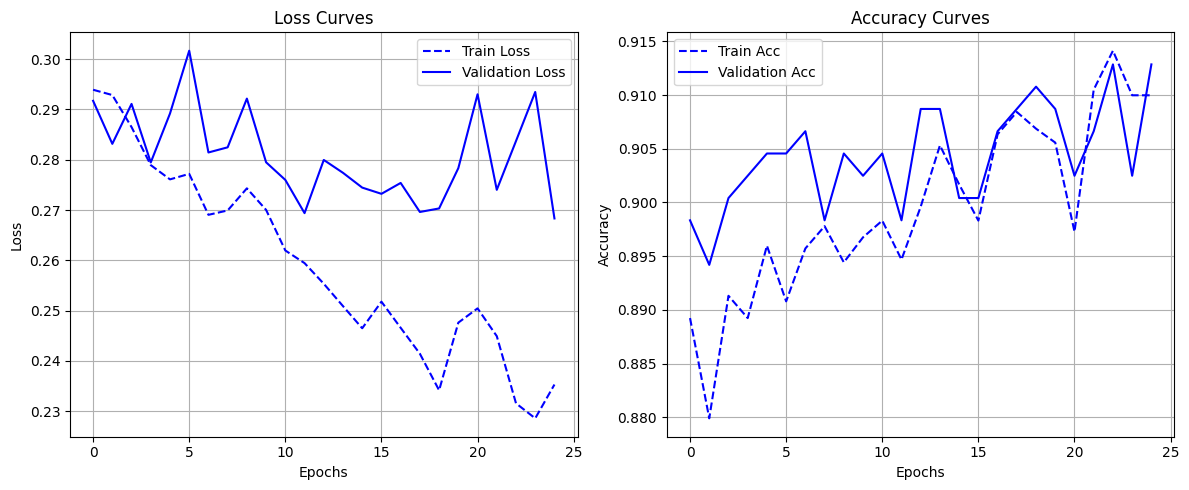

In [ ]:
plot_training_history(
    stages=[{'label': 'Stage 4', 'historial': history_ft3}],
    metrics=('loss', 'acc'),
    figsize=(12, 5),
    layout='horizontal'
)

Testing: 100%|██████████| 16/16 [00:04<00:00,  3.22it/s]



Loss: 0.2395
Classification Report:
                 precision    recall  f1-score   support

No fractura (0)       0.95      0.93      0.94       337
   Fractura (1)       0.85      0.88      0.87       145

       accuracy                           0.92       482
      macro avg       0.90      0.91      0.90       482
   weighted avg       0.92      0.92      0.92       482



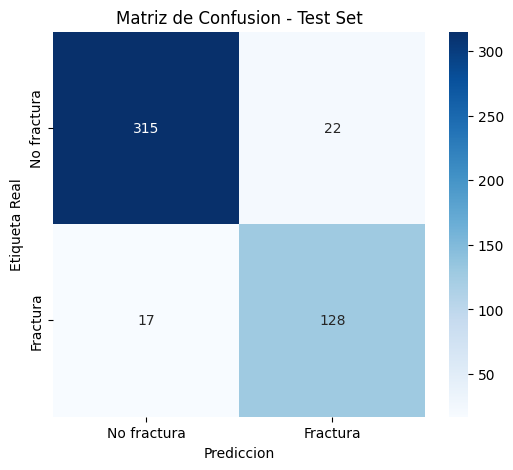

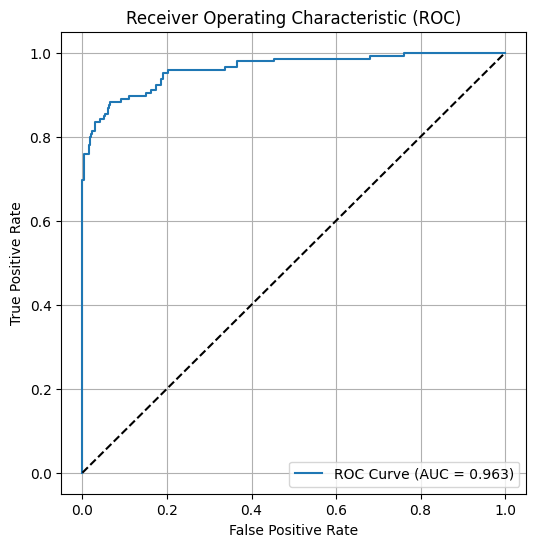

In [ ]:
if test_df.empty:
    print("El DataFrame de prueba está vacío. No hay datos para evaluar.")
else:
    resultados_test = evaluate_model(
        model, test_loader, criterion, device,
        model_path=best_model_path_ft2
    )

    all_labels = resultados_test['labels']
    all_preds = resultados_test['preds']
    all_probs = resultados_test['probs']

    show_classification_metrics(all_labels, all_preds, target_names=['No fractura (0)', 'Fractura (1)'])
    show_confusion_matrix(all_labels, all_preds, target_names=['No fractura', 'Fractura'])
    show_roc_curve(all_labels, all_probs)

### Visualización Comparativa del Fine-Tuning
Graficamos el progreso de la **Etapa 2 (Bloques Finales)** y la **Etapa 3 (Descongelación Profunda)**.

In [ ]:
with open(save_historial_path_tf, 'r') as f:
    history_tf = json.load(f)

with open(save_historial_path_ft1, 'r') as f:
    history_ft1 = json.load(f)

with open(save_historial_path_ft2, 'r') as f:
    history_ft2 = json.load(f)

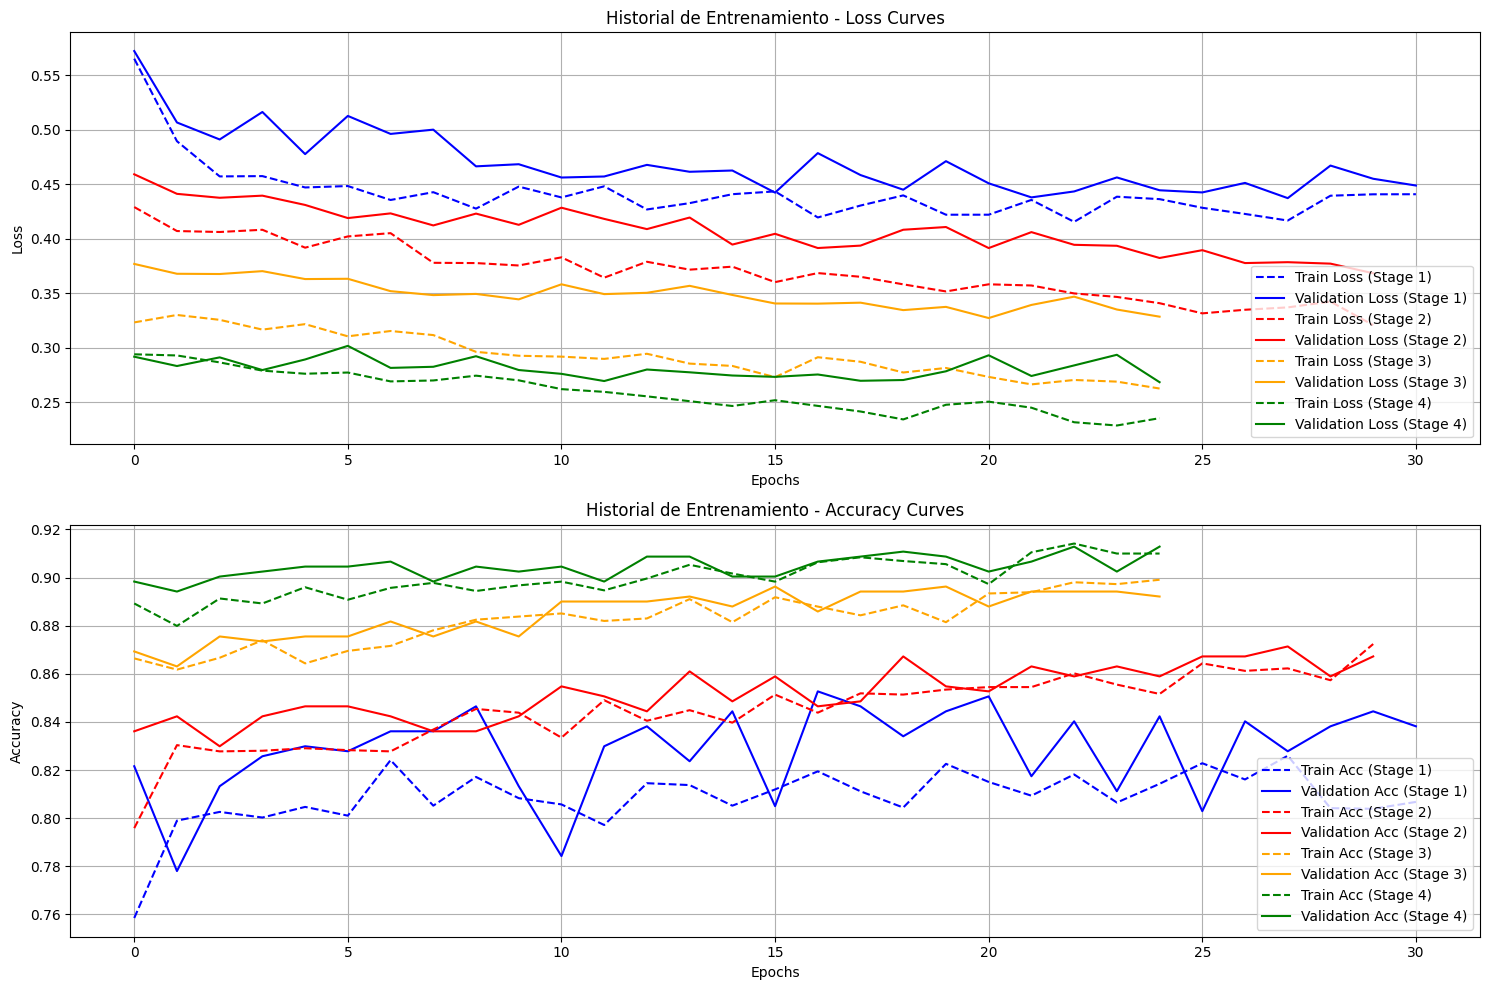

In [ ]:
plot_training_history(
    stages=[
        {'label': 'Stage 1', 'historial': history_tf},
        {'label': 'Stage 2', 'historial': history_ft1},
        {'label': 'Stage 3', 'historial': history_ft2},
        {'label': 'Stage 4', 'historial': history_ft3},
    ],
    metrics=('loss', 'acc'),
    layout='vertical'
)

### Pruebas de Inferencia
Carga del mejor modelo guardado durante las fases de fine-tuning para realizar predicciones sobre imágenes individuales.

In [9]:
model = RadriografiaEfficientNetB3(num_classes=2, model_name=MODEL_NAME, pretrained=False, freeze_backbone=False)
model.unfreze_backbone(phase_num=0)
model.to(device)
best_final_model_path = config["paths"]["model_path_ft3"]
model.load_state_dict(torch.load(best_final_model_path, map_location=device))

<All keys matched successfully>

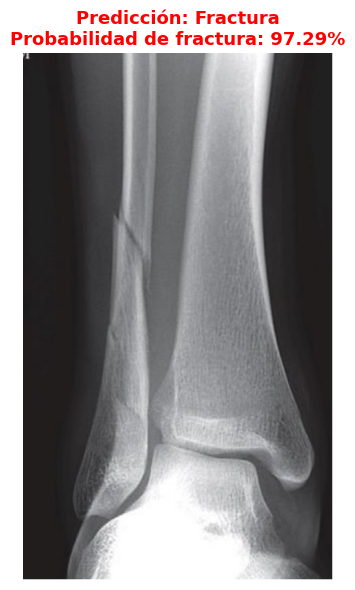

In [10]:
path_image_test = './test.jpg'

result = predict_and_show(model=model, image_path=path_image_test, device=device, transform=get_val_transform())

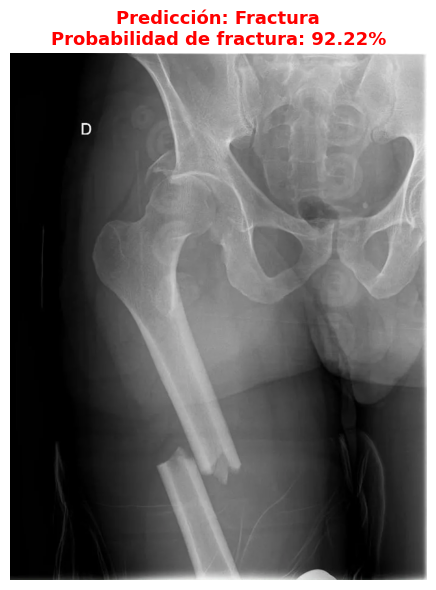

{'class_name': 'Fractura',
 'class_idx': 1,
 'prob_positive': 0.9221943616867065,
 'probs': array([0.07780562, 0.92219436], dtype=float32)}

In [11]:
path_image_test = './images.webp'

predict_and_show(model=model, image_path=path_image_test, device=device, transform=get_val_transform())

### Métricas Finales y Matriz de Confusión
Evaluación definitiva sobre el conjunto de test. Análisis del balance entre Precisión y Recall, crítico para la detección de fracturas.

Testing: 100%|██████████| 16/16 [00:04<00:00,  3.72it/s]



Loss: 0.2299
Classification Report:
                 precision    recall  f1-score   support

No fractura (0)       0.94      0.95      0.94       337
   Fractura (1)       0.88      0.85      0.87       145

       accuracy                           0.92       482
      macro avg       0.91      0.90      0.91       482
   weighted avg       0.92      0.92      0.92       482



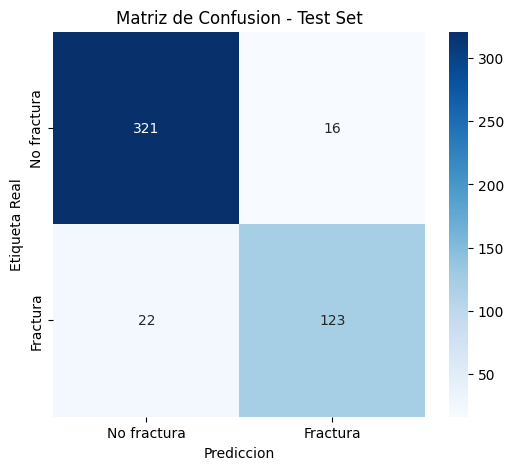

In [ ]:
data = evaluate_model(
    model, test_loader, criterion, device,
    model_path=best_final_model_path
)

show_classification_metrics(data['labels'], data['preds'], target_names=['No fractura (0)', 'Fractura (1)'])
show_confusion_matrix(data['labels'], data['preds'], target_names=['No fractura', 'Fractura'])

In [5]:
model = RadriografiaEfficientNetB3(num_classes=2, model_name=MODEL_NAME, pretrained=False, freeze_backbone=False)
model.unfreze_backbone(phase_num=0)
model.to(device)
best_final_model_path = config["paths"]["model_path_ft3"]
model.load_state_dict(torch.load(best_final_model_path, map_location=device))

<All keys matched successfully>

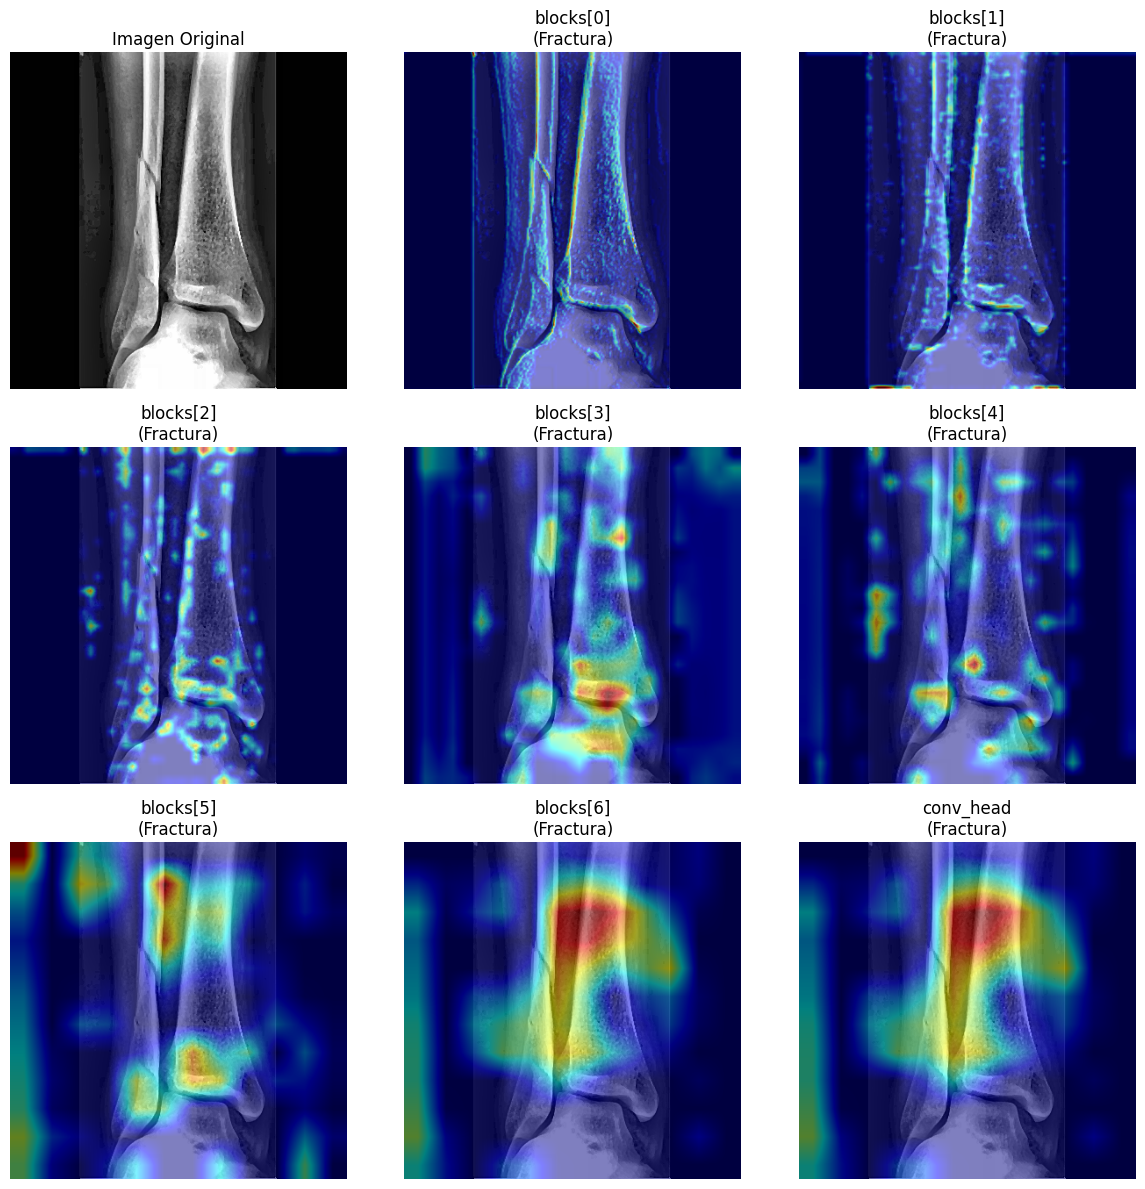

In [8]:
path_image_test = './test.jpg'

show_gradcam(
    model=model,
    image_path=path_image_test,
    device=device,
    transform=get_val_transform(),
    layer_names_and_layers={
        'blocks[0]': model.model.blocks[0],
        'blocks[1]': model.model.blocks[1],
        'blocks[2]': model.model.blocks[2],
        'blocks[3]': model.model.blocks[3],
        'blocks[4]': model.model.blocks[4],
        'blocks[5]': model.model.blocks[5],
        'blocks[6]': model.model.blocks[6],
        'conv_head': model.model.conv_head,
    },
    cols=3,
    subplot_size=4
)

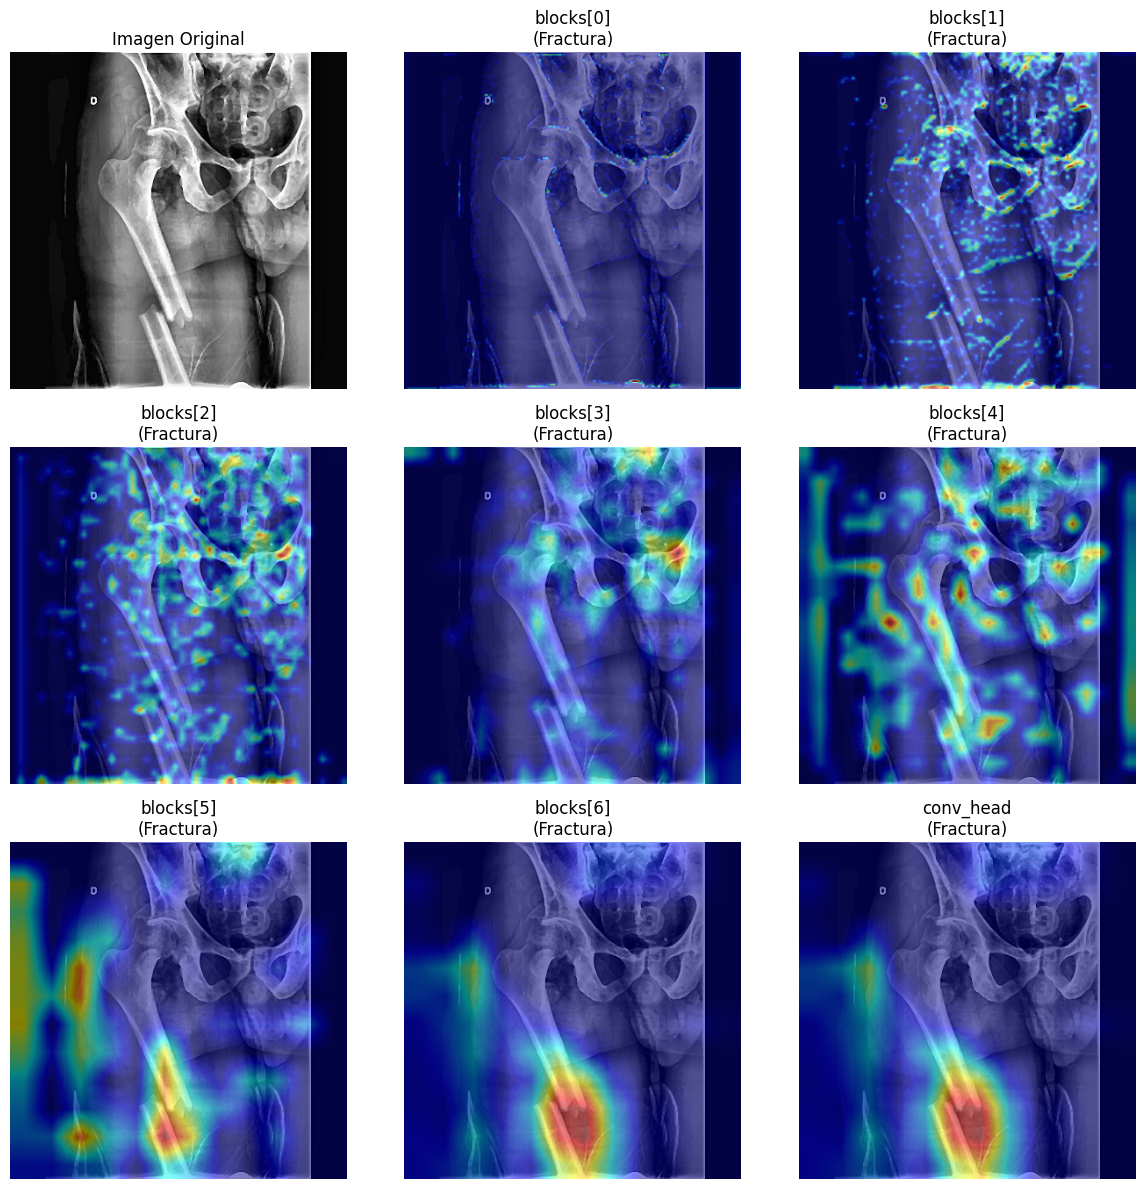

In [7]:
path_image_test = './images.webp'

show_gradcam(
    model=model,
    image_path=path_image_test,
    device=device,
    transform=get_val_transform(),
    layer_names_and_layers={
        'blocks[0]': model.model.blocks[0],
        'blocks[1]': model.model.blocks[1],
        'blocks[2]': model.model.blocks[2],
        'blocks[3]': model.model.blocks[3],
        'blocks[4]': model.model.blocks[4],
        'blocks[5]': model.model.blocks[5],
        'blocks[6]': model.model.blocks[6],
        'conv_head': model.model.conv_head,
    },
    cols=3,
    subplot_size=4
)